# Cell 1 — Libraries

In [1]:
# Task 4: Sentiment Analysis - Twitter Dataset
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Cell 2 — Data Loading

In [2]:
# Step 2: Data Loading
df = pd.read_csv('Twitter_Data.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nSentiment Distribution:")
print(df['category'].value_counts())

Shape: (162980, 2)

Columns: ['clean_text', 'category']

First 5 rows:
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0

Sentiment Distribution:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


# Cell 3 — Data Cleaning

In [3]:
# Step 3: Data Cleaning
print("Missing Values:")
print(df.isnull().sum())

# Remove missing values
df = df.dropna()
print("\nAfter Cleaning Shape:", df.shape)

# Rename columns
df.columns = ['text', 'sentiment']

# Convert sentiment to integer
df['sentiment'] = df['sentiment'].astype(int)

print("\nSentiment Distribution After Cleaning:")
print(df['sentiment'].value_counts())

Missing Values:
clean_text    4
category      7
dtype: int64

After Cleaning Shape: (162969, 2)

Sentiment Distribution After Cleaning:
sentiment
 1    72249
 0    55211
-1    35509
Name: count, dtype: int64


# Cell 4 — Visualization

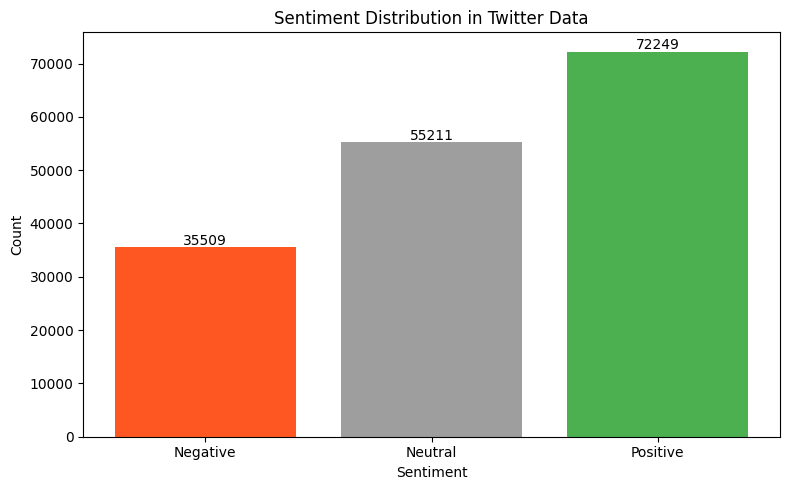

In [4]:
# Step 4: Visualization

# Graph 1 - Sentiment Distribution
plt.figure(figsize=(8,5))
colors = ['#FF5722', '#9E9E9E', '#4CAF50']
labels = ['Negative', 'Neutral', 'Positive']
values = [df[df['sentiment']==-1].shape[0],
          df[df['sentiment']==0].shape[0],
          df[df['sentiment']==1].shape[0]]

plt.bar(labels, values, color=colors)
plt.title('Sentiment Distribution in Twitter Data')
plt.xlabel('Sentiment')
plt.ylabel('Count')
for i, v in enumerate(values):
    plt.text(i, v + 500, str(v), ha='center')
plt.tight_layout()
plt.show()

# Cell 5 — Pie Chart

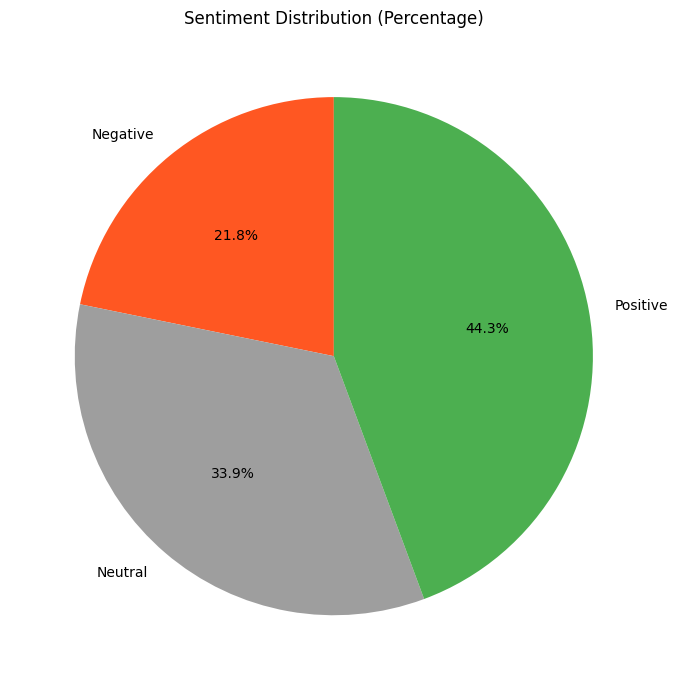

In [5]:
# Graph 2 - Pie Chart
plt.figure(figsize=(7,7))
plt.pie(values, labels=labels, 
        colors=colors, autopct='%1.1f%%',
        startangle=90)
plt.title('Sentiment Distribution (Percentage)')
plt.tight_layout()
plt.show()

# Cell 6 — ML Model (Naive Bayes)

In [6]:
# Step 5: Machine Learning Model

# Prepare data
X = df['text']
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Naive Bayes Model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

print("Model Accuracy:")
print(classification_report(y_test, y_pred))

Model Accuracy:
              precision    recall  f1-score   support

          -1       0.91      0.42      0.57      7152
           0       0.88      0.66      0.76     11067
           1       0.65      0.95      0.77     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



# Cell 7 — Confusion Matrix

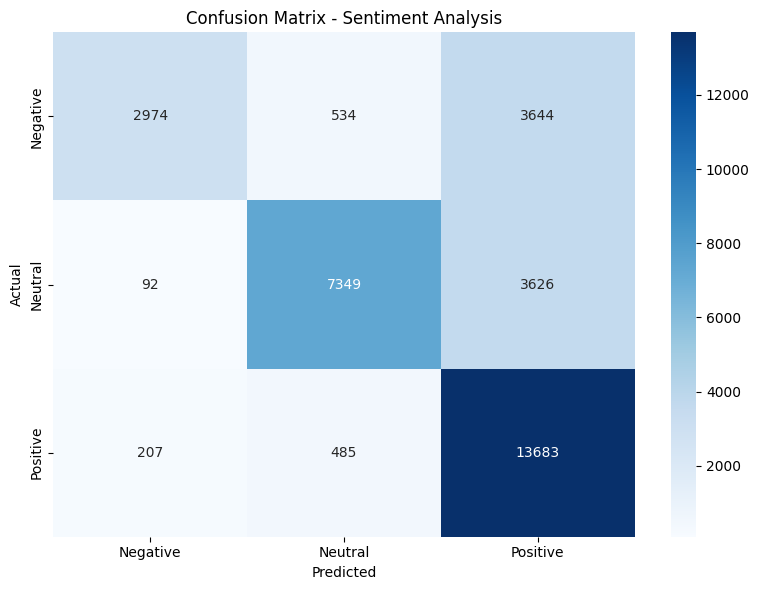

In [7]:
# Graph 3 - Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('Confusion Matrix - Sentiment Analysis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Cell 8 — Recommendations

In [8]:
# Step 6: Insights & Recommendations
print("=" * 55)
print("SENTIMENT ANALYSIS - INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print("""
MODEL PERFORMANCE:
- Overall Accuracy: 74%
- Best at detecting Positive sentiment (95% recall)
- Good precision for Negative sentiment (91%)

KEY INSIGHTS:
1. POSITIVE TWEETS DOMINATE
   - 44.3% tweets are positive
   - People mostly share positive opinions

2. NEGATIVE TWEETS LEAST
   - Only 21.8% tweets are negative
   - Negative opinions are minority

3. MODEL STRENGTHS
   - Naive Bayes works well for text classification
   - TF-IDF captures important keywords effectively

RECOMMENDATIONS:
1. Use model for real-time social media monitoring
2. Improve negative sentiment detection
3. Add more training data for better accuracy
4. Try deep learning for higher accuracy
""")
print("=" * 55)
print("Task 4 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

SENTIMENT ANALYSIS - INSIGHTS & RECOMMENDATIONS

MODEL PERFORMANCE:
- Overall Accuracy: 74%
- Best at detecting Positive sentiment (95% recall)
- Good precision for Negative sentiment (91%)

KEY INSIGHTS:
1. POSITIVE TWEETS DOMINATE
   - 44.3% tweets are positive
   - People mostly share positive opinions

2. NEGATIVE TWEETS LEAST
   - Only 21.8% tweets are negative
   - Negative opinions are minority

3. MODEL STRENGTHS
   - Naive Bayes works well for text classification
   - TF-IDF captures important keywords effectively

RECOMMENDATIONS:
1. Use model for real-time social media monitoring
2. Improve negative sentiment detection
3. Add more training data for better accuracy
4. Try deep learning for higher accuracy

Task 4 Complete! - Suraj Kumar | OIB/J2/IP2626
